#### Biggest strides in decreasing CO2 output

**Which countries are making the biggest strides in decreasing CO2 output?**

You'll need to find the relative CO2 output for each country to be able to calculate this. But countries can have growing and shrinking populations too, so it's probably a good idea to take this into account as well.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

In [26]:
# Import the original CO Emissions per Capita data
# df_original_data = pd.read_csv('https://raw.githubusercontent.com/majavanput/co2-emissions/main/data/co-emissions-per-capita.csv')
df_original_data = pd.read_csv('../data/co-emissions-per-capita.csv')

In [30]:
# Print information about the DataFrame
df_original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26509 entries, 0 to 26508
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    26509 non-null  str    
 1   Code                      25363 non-null  str    
 2   Year                      26509 non-null  int64  
 3   CO₂ emissions per capita  26509 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 828.5 KB


In [33]:
# Overview of missing values per column
for name, values in df_original_data.items():
  print(f'Missing values in column {name}: ', df_original_data[name].isnull().sum())

# Total number of missing values in dataset
total_nan = df_original_data.isnull().sum().sum()
print(f"Total number of NaN values in the DataFrame: {total_nan}")

Missing values in column Entity:  0
Missing values in column Code:  1146
Missing values in column Year:  0
Missing values in column CO₂ emissions per capita:  0
Total number of NaN values in the DataFrame: 1146


In [ ]:
df_co2_emissions = df_original_data.copy()

# Drop unnecessary columns
df_co2_emissions.drop(columns=['Code'], inplace=True)

In [32]:
df_co2_emissions.head()

,Entity,Year,CO₂ emissions per capita
0,Afghanistan,1949,0.001992
1,Afghanistan,1950,0.010837
2,Afghanistan,1951,0.011625
3,Afghanistan,1952,0.011468
4,Afghanistan,1953,0.013123


In [ ]:
# Relative change CO2 1990 vs 2020
df_co2_emissions_change = df_original_data.copy()
#df_co2_change["change_1990_2020"] = df_co2_change[df_co2_change["year"] == 2020] / df_co2_change[df_co2_change["year"] == 1990]

co2 = df_co2_emissions_change[df_co2_emissions_change["Year"].isin([1990, 2000, 2010, 2020])]

co2 = co2.pivot(
  index=["Entity", "Code"],
  columns="Year",
  values="CO₂ emissions per capita"
)

co2_reset = co2.reset_index()

co2_reset["relative_change_1990_2020"] = (co2_reset[2020] - co2_reset[1990]) / co2_reset[1990]
co2_reset["relative_change_2000_2020"] = (co2_reset[2020] - co2_reset[2000]) / co2_reset[2000]
co2_reset["relative_change_2010_2020"] = (co2_reset[2020] - co2_reset[2010]) / co2_reset[2010]

display(co2_reset.head())

Year,Entity,Code,1990,2000,2010,2020,relative_change_1990_2020,relative_change_2000_2020,relative_change_2010_2020
0,Afghanistan,AFG,0.168054,0.052017,0.295742,0.284590,0.693438,4.471045,-0.037711
1,Africa,OWID_AFR,1.020606,1.119205,1.136341,0.993473,-0.026585,-0.112340,-0.125727
2,Albania,ALB,1.684155,0.955397,1.644685,1.693982,0.005835,0.773067,0.029974
3,Algeria,DZA,2.990726,2.735981,3.256510,3.885795,0.299281,0.420257,0.193239
4,Andorra,AND,7.660027,7.974552,6.399643,4.876055,-0.363442,-0.388548,-0.238074


In [20]:
co2_reset.head()

Year,Entity,Code,1990,2000,2010,2020,relative_change_1990_2020,relative_change_2000_2020,relative_change_2010_2020
0,Afghanistan,AFG,0.168054,0.052017,0.295742,0.284590,0.693438,4.471045,-0.037711
1,Africa,OWID_AFR,1.020606,1.119205,1.136341,0.993473,-0.026585,-0.112340,-0.125727
2,Albania,ALB,1.684155,0.955397,1.644685,1.693982,0.005835,0.773067,0.029974
3,Algeria,DZA,2.990726,2.735981,3.256510,3.885795,0.299281,0.420257,0.193239
4,Andorra,AND,7.660027,7.974552,6.399643,4.876055,-0.363442,-0.388548,-0.238074


In [21]:
co2_top_10_1990_2020 = co2_reset[["Entity", 1990, 2000, 2020, "relative_change_1990_2020"]].sort_values(by="relative_change_1990_2020", ascending=True).head(10)
display(co2_top_10_1990_2020)

Year,Entity,1990,2000,2020,relative_change_1990_2020
136,Moldova,8.201354,0.843678,1.665985,-0.796865
112,Kyrgyzstan,4.306276,0.910472,1.252748,-0.709088
66,Estonia,23.502500,11.074418,6.917664,-0.705663
216,Ukraine,13.572912,5.764382,4.635197,-0.658496
52,Curacao,30.812616,34.110470,10.851662,-0.647818
230,Zimbabwe,1.532660,1.161661,0.546847,-0.643204
144,Nauru,12.916122,8.632178,4.711530,-0.635221
55,Democratic Republic of Congo,0.115826,0.033752,0.044846,-0.612814
123,Luxembourg,30.937780,19.952950,12.795942,-0.586398
204,Tajikistan,2.279526,0.355856,0.966562,-0.575981


In [22]:
co2_top_10_2000_2020 = co2_reset[["Entity", 1990, 2000, 2020, "relative_change_2000_2020"]].sort_values(by="relative_change_2000_2020", ascending=True).head(10)
display(co2_top_10_2000_2020)

Year,Entity,1990,2000,2020,relative_change_2000_2020
10,Aruba,7.560852,26.787004,7.641079,-0.714747
52,Curacao,30.812616,34.110470,10.851662,-0.681867
228,Yemen,0.689238,0.806749,0.297691,-0.630999
124,Macao,2.567032,3.493785,1.512655,-0.567044
202,Syria,2.962390,3.277267,1.536593,-0.531136
230,Zimbabwe,1.532660,1.161661,0.546847,-0.529254
56,Denmark,10.402008,10.170421,4.852874,-0.522844
224,Venezuela,6.095922,5.826397,2.844218,-0.511839
130,Malta,6.597783,6.171891,3.089255,-0.499464
5,Angola,0.437787,0.987665,0.494732,-0.499089


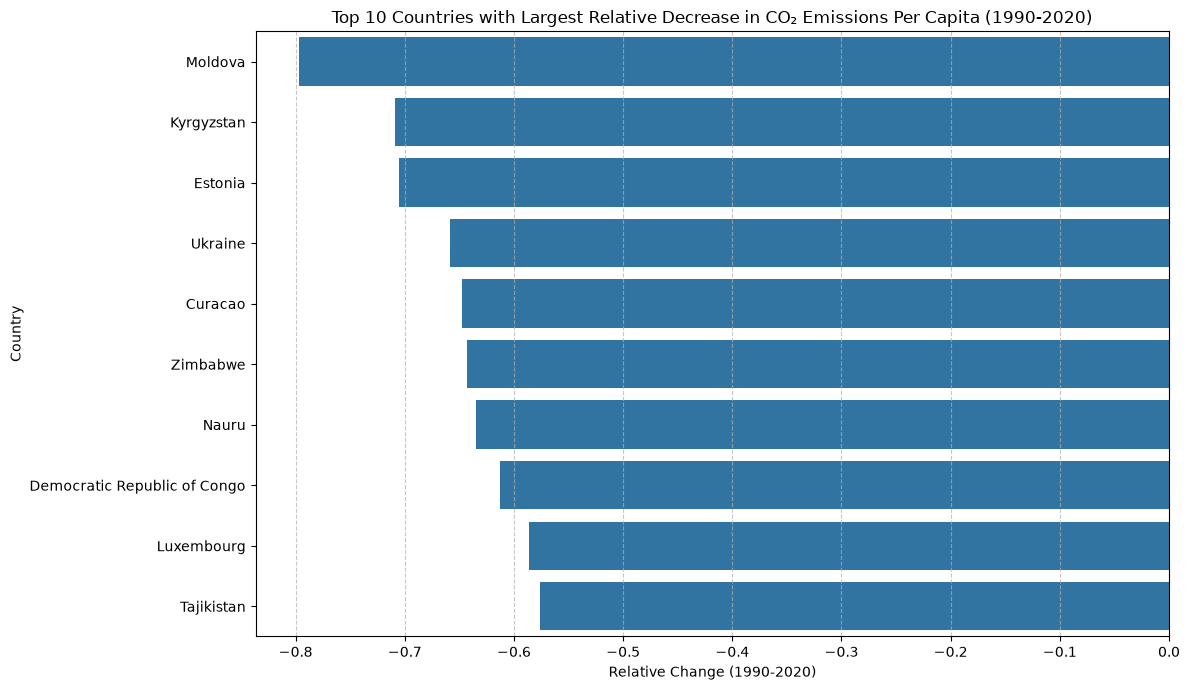

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='relative_change_1990_2020', y='Entity', data=co2_top_10_1990_2020)
plt.title('Top 10 Countries with Largest Relative Decrease in CO₂ Emissions Per Capita (1990-2020)')
plt.xlabel('Relative Change (1990-2020)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

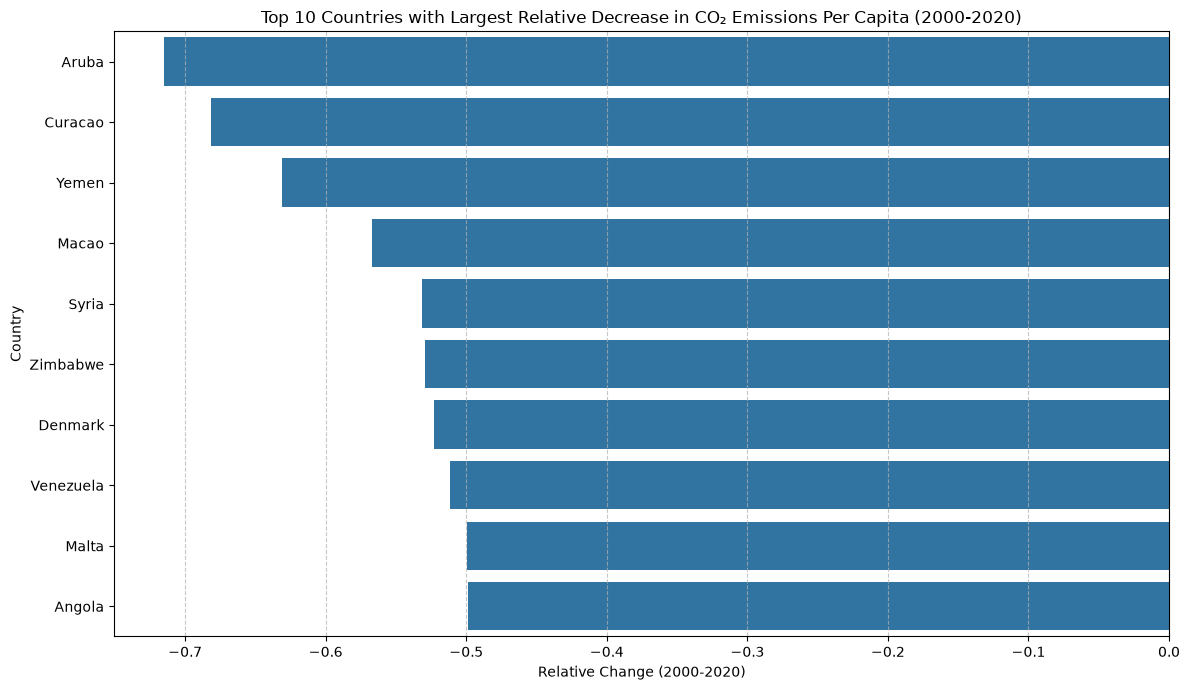

In [24]:
plt.figure(figsize=(12, 7))
sns.barplot(x='relative_change_2000_2020', y='Entity', data=co2_top_10_2000_2020)
plt.title('Top 10 Countries with Largest Relative Decrease in CO₂ Emissions Per Capita (2000-2020)')
plt.xlabel('Relative Change (2000-2020)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()